In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 

parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': 'Personal_API_KEY',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

In [2]:
type(data)

dict

In [3]:
import pandas as pd


#This allows to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.001262e+07,2.001262e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12596,1,2026-04-07T13:42:00.000Z,None,NaN,NaN,NaN,1.368780e+12,"[mineable, pow, sha-256, store-of-value, state...",68395.821982,3.376932e+10,3.374732e+10,2.200512e+07,-3.6326,0.037246,-1.311665,2.019149,2.243501,1.628335,-25.712145,1.368780e+12,58.4919,1.436312e+12,None,2026-04-07T13:42:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:44:42.160588
1,1027,Ethereum,ETH,ethereum,True,1.206912e+08,1.206912e+08,NaN,2015-08-07T00:00:00.000Z,11718,2,2026-04-07T13:42:00.000Z,None,NaN,NaN,NaN,2.510613e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2080.195925,1.710826e+10,1.699389e+10,1.143739e+08,5.8394,-0.124636,-2.872452,0.682096,7.760201,6.470346,-35.315609,2.510613e+11,10.7286,2.510613e+11,None,2026-04-07T13:42:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:44:42.160588
2,825,Tether USDt,USDT,tether,True,1.841515e+11,1.889176e+11,NaN,2015-02-25T00:00:00.000Z,176770,3,2026-04-07T13:42:00.000Z,None,NaN,NaN,NaN,1.888988e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999900,6.952001e+10,6.782275e+10,1.697259e+09,1.1428,0.013494,0.007218,0.079945,-0.011909,0.078972,0.064574,1.841331e+11,7.8685,1.888988e+11,None,2026-04-07T13:42:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-07 13:44:42.160588
3,1839,BNB,BNB,bnb,False,1.363568e+08,1.363568e+08,1.363568e+08,2017-07-25T00:00:00.000Z,3176,4,2026-04-07T13:42:00.000Z,None,NaN,NaN,NaN,8.158780e+10,"[marketplace, centralized-exchange, payments, ...",598.340551,1.578609e+09,1.538565e+09,4.004344e+07,6.0987,0.305434,-1.160932,-1.709538,-2.585008,-7.306454,-33.910066,8.158780e+10,3.4865,8.158780e+10,None,2026-04-07T13:42:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:44:42.160588
4,52,XRP,XRP,xrp,False,6.140553e+10,9.998569e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1821,5,2026-04-07T13:43:00.000Z,None,NaN,NaN,NaN,1.307356e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.307543,1.631336e+09,1.628553e+09,2.782981e+06,-17.6103,0.101405,-2.748195,-1.051439,-2.861267,-8.897541,-41.887867,8.029039e+10,3.4319,1.307543e+11,None,2026-04-07T13:43:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:44:42.160588
5,3408,USDC,USDC,usd-coin,False,7.790366e+10,7.790366e+10,NaN,2018-10-08T00:00:00.000Z,38542,6,2026-04-07T13:42:00.000Z,None,NaN,6.090122e+10,6.089275e+10,7.789282e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999861,1.134827e+10,9.311887e+09,2.036384e+09,31.5949,0.026683,0.001474,0.001857,-0.010582,-0.009694,0.009158,7.789282e+10,3.3286,7.789282e+10,None,2026-04-07T13:42:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-04-07 13:44:42.160588
6,5426,Solana,SOL,solana,True,5.735896e+08,6.238581e+08,NaN,2020-04-10T00:00:00.000Z,1114,7,2026-04-07T13:41:00.000Z,None,NaN,5.252369e+08,4.153500e+10,4.933383e+10,"[pos, platform, solana-ecosystem, cms-holdings...",79.078596,3.424732e+09,3.424688e+09,4.377872e+04,-0.9023,0.069450,-3.975888,-2.673633,-3.160601,-4.764357,-42.748978,4.535866e+10,1.9383,4.933383e+10,None,2026-04-07T13:41:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:44:42.160588
7,1958,TRON,TRX,tron,True,9.476908e+10,9.476909e+10,NaN,2017-09-13T00:00:00.000Z,1319,8,2026-04-07T13:43:00.000Z,None,NaN,9.4667

In [9]:

def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

    
    # Use this if we just want to keep it in a dataframe
#     df2 = pd.json_normalize(data['data'])
#     df2['Timestamp'] = pd.to_datetime('now')
#     df = df.append(df2)


    # Use this if we want to create a csv and append data to it
    df = pd.json_normalize(data['data'])
    df['timestamp'] = pd.to_datetime('now')
    df

    if not os.path.isfile(r'/Users/macbookcuakhoi/Documents/Crypto_API_project/API.csv'):
        df.to_csv(r'/Users/macbookcuakhoi/Documents/Crypto_API_project/API.csv', header='column_names')
    else:
        df.to_csv(r'/Users/macbookcuakhoi/Documents/Crypto_API_project/API.csv', mode='a', header=False)

In [10]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
exit()

API Runner completed
API Runner completed
API Runner completed
API Runner completed
API Runner completed


KeyboardInterrupt: 

In [51]:
df72 = pd.read_csv(r'/Users/macbookcuakhoi/Documents/Crypto_API_project/API.csv')

In [60]:
df.head()

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20012621.00000,20012621.00000,21000000.00000,2010-07-13T00:00:00.000Z,12596,1,2026-04-07T13:54:00.000Z,None,NaN,NaN,NaN,1367952623366.73999,"[mineable, pow, sha-256, store-of-value, state...",68354.49606,33649545530.47485,33626307406.86340,23238123.61145,-4.72810,0.03657,-1.52117,1.53592,1.75938,1.36378,-25.71003,1367952623366.73999,58.54430,1435444417335.51001,None,2026-04-07T13:54:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774
1,1027,Ethereum,ETH,ethereum,True,120691190.90800,120691190.90800,NaN,2015-08-07T00:00:00.000Z,11718,2,2026-04-07T13:53:00.000Z,None,NaN,NaN,NaN,251081519847.60001,"[pos, smart-contracts, ethereum-ecosystem, coi...",2080.36326,17004190632.16499,16889503924.63507,114686707.52992,3.00500,0.02182,-3.04738,0.23979,7.06403,6.55119,-35.18294,251081519847.60001,10.74550,251081519847.60001,None,2026-04-07T13:53:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774
2,825,Tether USDt,USDT,tether,True,184151480311.99927,188917624595.19785,NaN,2015-02-25T00:00:00.000Z,176772,3,2026-04-07T13:52:00.000Z,None,NaN,NaN,NaN,188893211762.92999,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99987,69484957424.34750,67777022014.28924,1707935410.05823,0.12550,0.00574,0.00337,0.08065,-0.00082,0.08624,0.05938,184127683383.51999,7.87780,188893211762.92999,None,2026-04-07T13:52:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-07 13:55:32.558774
3,1839,BNB,BNB,bnb,False,136356802.26000,136356802.26000,136356803.25000,2017-07-25T00:00:00.000Z,3176,4,2026-04-07T13:53:00.000Z,None,NaN,NaN,NaN,81456514771.72000,"[marketplace, centralized-exchange, payments, ...",597.37771,1579018295.83528,1539385683.05648,39632612.77881,5.76210,0.11614,-1.44803,-2.16637,-2.99193,-7.43810,-33.93739,81456514771.72000,3.48610,81456515363.12000,None,2026-04-07T13:53:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774
4,52,XRP,XRP,xrp,False,61405531717.00000,99985687636.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1821,5,2026-04-07T13:53:00.000Z,None,NaN,NaN,NaN,130576351188.95000,"[medium-of-exchange, enterprise-solutions, xrp...",1.30595,1631963083.12868,1629134442.40756,2828640.72112,-17.62280,0.06759,-2.96256,-1.32150,-3.15828,-8.98740,-41.85760,80192580198.21001,3.43200,130595042426.78999,None,2026-04-07T13:53:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774


In [13]:
# One thing I noticed was the scientific notation. I like it, but I want to be able to see the numbers in this case

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [59]:
df.head()

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20012621.00000,20012621.00000,21000000.00000,2010-07-13T00:00:00.000Z,12596,1,2026-04-07T13:54:00.000Z,None,NaN,NaN,NaN,1367952623366.73999,"[mineable, pow, sha-256, store-of-value, state...",68354.49606,33649545530.47485,33626307406.86340,23238123.61145,-4.72810,0.03657,-1.52117,1.53592,1.75938,1.36378,-25.71003,1367952623366.73999,58.54430,1435444417335.51001,None,2026-04-07T13:54:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774
1,1027,Ethereum,ETH,ethereum,True,120691190.90800,120691190.90800,NaN,2015-08-07T00:00:00.000Z,11718,2,2026-04-07T13:53:00.000Z,None,NaN,NaN,NaN,251081519847.60001,"[pos, smart-contracts, ethereum-ecosystem, coi...",2080.36326,17004190632.16499,16889503924.63507,114686707.52992,3.00500,0.02182,-3.04738,0.23979,7.06403,6.55119,-35.18294,251081519847.60001,10.74550,251081519847.60001,None,2026-04-07T13:53:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774
2,825,Tether USDt,USDT,tether,True,184151480311.99927,188917624595.19785,NaN,2015-02-25T00:00:00.000Z,176772,3,2026-04-07T13:52:00.000Z,None,NaN,NaN,NaN,188893211762.92999,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99987,69484957424.34750,67777022014.28924,1707935410.05823,0.12550,0.00574,0.00337,0.08065,-0.00082,0.08624,0.05938,184127683383.51999,7.87780,188893211762.92999,None,2026-04-07T13:52:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-07 13:55:32.558774
3,1839,BNB,BNB,bnb,False,136356802.26000,136356802.26000,136356803.25000,2017-07-25T00:00:00.000Z,3176,4,2026-04-07T13:53:00.000Z,None,NaN,NaN,NaN,81456514771.72000,"[marketplace, centralized-exchange, payments, ...",597.37771,1579018295.83528,1539385683.05648,39632612.77881,5.76210,0.11614,-1.44803,-2.16637,-2.99193,-7.43810,-33.93739,81456514771.72000,3.48610,81456515363.12000,None,2026-04-07T13:53:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774
4,52,XRP,XRP,xrp,False,61405531717.00000,99985687636.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1821,5,2026-04-07T13:53:00.000Z,None,NaN,NaN,NaN,130576351188.95000,"[medium-of-exchange, enterprise-solutions, xrp...",1.30595,1631963083.12868,1629134442.40756,2828640.72112,-17.62280,0.06759,-2.96256,-1.32150,-3.15828,-8.98740,-41.85760,80192580198.21001,3.43200,130595042426.78999,None,2026-04-07T13:53:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-07 13:55:32.558774


In [35]:
# Now let's look at the coin trends over time

df3 = df72.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.02617,-1.56421,1.63247,1.67183,1.34020,-25.78695
Ethereum,-0.05979,-3.12148,0.25166,6.85998,6.31095,-35.27493
Tether USDt,0.00153,-0.00124,0.07606,-0.00484,0.07987,0.06168
BNB,0.09885,-1.46083,-2.12437,-2.98266,-7.44238,-33.96324
XRP,0.04762,-2.93716,-1.27249,-3.15664,-8.92456,-41.89228
USDC,-0.00426,0.00140,0.00957,-0.00901,-0.01021,0.00317
Solana,-0.00962,-4.26192,-3.32577,-3.67047,-5.43519,-42.82833
TRON,-0.15914,-1.22947,-0.29971,9.34695,16.48855,5.95491
Dogecoin,0.11590,-2.04263,-0.85076,2.21387,-4.87338,-38.81512


In [58]:
df4 = df3.stack()
df4.head()

name                                 
Bitcoin  quote.USD.percent_change_1h     0.02617
         quote.USD.percent_change_24h   -1.56421
         quote.USD.percent_change_7d     1.63247
         quote.USD.percent_change_30d    1.67183
         quote.USD.percent_change_60d    1.34020
dtype: float64

In [37]:
type(df4)

pandas.core.series.Series

In [57]:
df5 = df4.to_frame(name='values')
df5.head()

values
name                                         
Bitcoin quote.USD.percent_change_1h   0.02617
        quote.USD.percent_change_24h -1.56421
        quote.USD.percent_change_7d   1.63247
        quote.USD.percent_change_30d  1.67183
        quote.USD.percent_change_60d  1.34020

In [39]:
df5.count()

values    90
dtype: int64

In [61]:
df6 = df5.reset_index()
df6.head()

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.02617
1,Bitcoin,quote.USD.percent_change_24h,-1.56421
2,Bitcoin,quote.USD.percent_change_7d,1.63247
3,Bitcoin,quote.USD.percent_change_30d,1.67183
4,Bitcoin,quote.USD.percent_change_60d,1.34020


In [55]:
# Change the column name

df7 = df6.rename(columns={'level_1': 'percent_change'})

In [56]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7.head()

,name,percent_change,values
0,Bitcoin,1h,0.02617
1,Bitcoin,24h,-1.56421
2,Bitcoin,7d,1.63247
3,Bitcoin,30d,1.67183
4,Bitcoin,60d,1.34020


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

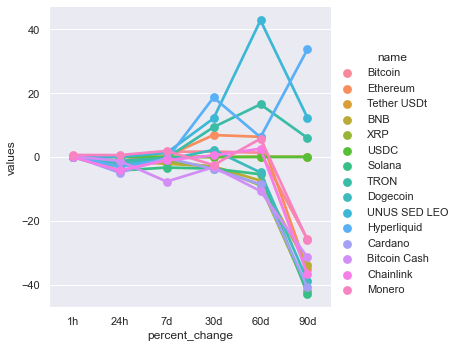

In [44]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [48]:
# Now to do something much simpler
# we are going to create a dataframe with the columns we want

df10 = df72[['name', 'quote.USD.price', 'timestamp']].copy()
df10 = df10.query("name == 'Bitcoin'").copy()

df10['timestamp'] = pd.to_datetime(df10['timestamp'])
df10 = df10.sort_values('timestamp')

df10

,name,quote.USD.price,timestamp
0,Bitcoin,68205.89300,2026-04-07 13:51:30.665761
15,Bitcoin,68305.11987,2026-04-07 13:52:31.494590
30,Bitcoin,68305.11987,2026-04-07 13:53:31.864686
45,Bitcoin,68314.62583,2026-04-07 13:54:32.196399
60,Bitcoin,68354.49606,2026-04-07 13:55:32.558774


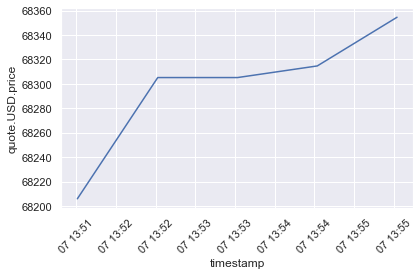

In [50]:
import matplotlib.dates as mdates

sns.set_theme(style="darkgrid")
ax = sns.lineplot(x='timestamp', y='quote.USD.price', data=df10)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()